In [1]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import nltk
#nltk.download()
import sklearn


from tensorflow import keras
from tensorflow.keras.preprocessing.text import text_to_word_sequence
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [3]:

dataset = pd.read_csv('BBC News Train.csv')
test_set = pd.read_csv("BBC News Test.csv")

In [4]:
dataset.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [5]:
target_category = dataset['Category'].unique()
print(target_category)

['business' 'tech' 'politics' 'sport' 'entertainment']


In [6]:
dataset['categoryId'] = dataset['Category'].factorize()[0]
dataset.head()

,ArticleId,Text,Category,categoryId
0,1833,worldcom ex-boss launches defence lawyers defe...,business,0
1,154,german business confidence slides german busin...,business,0
2,1101,bbc poll indicates economic gloom citizens in ...,business,0
3,1976,lifestyle governs mobile choice faster bett...,tech,1
4,917,enron bosses in $168m payout eighteen former e...,business,0


In [7]:
category = dataset[["Category","categoryId"]].drop_duplicates().sort_values('categoryId')
category

,Category,categoryId
0,business,0
3,tech,1
5,politics,2
6,sport,3
7,entertainment,4


In [8]:
dataset.groupby('Category').categoryId.count()

,categoryId
Category,
business,336
entertainment,273
politics,274
sport,346
tech,261


# Data Visualization

<Axes: xlabel='Category'>

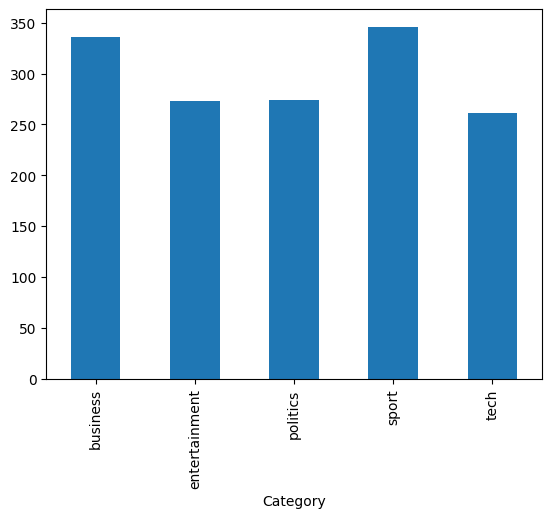

In [9]:
dataset.groupby('Category').categoryId.count().plot.bar(ylim=0)

In [10]:
text = dataset["Text"]
text.head()

,Text
0,worldcom ex-boss launches defence lawyers defe...
1,german business confidence slides german busin...
2,bbc poll indicates economic gloom citizens in ...
3,lifestyle governs mobile choice faster bett...
4,enron bosses in $168m payout eighteen former e...


In [11]:
category = dataset["Category"]
category.head()

,Category
0,business
1,business
2,business
3,tech
4,business


# Data Preprocessing

In [12]:
def preprocessDataset(train_text):

    #word tokenization using text-to-word-sequence
    train_text= str(train_text)
    tokenized_train_set = text_to_word_sequence(train_text,filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',lower=True,split=" ")

    #stop word removal
    stop_words = set(stopwords.words('english'))
    stopwordremove = [i for i in tokenized_train_set if not i in stop_words]


    #join words into sentence
    stopwordremove_text = ' '.join(stopwordremove)


    #remove numbers
    numberremove_text = ''.join(c for c in stopwordremove_text if not c.isdigit())


    #--Stemming--
    stemmer= PorterStemmer()

    stem_input=nltk.word_tokenize(numberremove_text)
    stem_text=' '.join([stemmer.stem(word) for word in stem_input])


    lemmatizer = WordNetLemmatizer()

    def get_wordnet_pos(word):
        """Map POS tag to first character lemmatize() accepts"""
        tag = nltk.pos_tag([word])[0][1][0].upper()
        tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}

        return tag_dict.get(tag, wordnet.NOUN)

    lem_input = nltk.word_tokenize(stem_text)
    lem_text= ' '.join([lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in lem_input])

    return lem_text



# Split train set

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(text,category, test_size = 0.2, random_state = 60,shuffle=True, stratify=category)

print(len(X_train))
print(len(X_test))

1192
298


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

### SVM

In [15]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

modelSVC = Pipeline([('tfidf', TfidfVectorizer()),
               ('clf', SVC()),
              ])


#modelSVC = SVC()
modelSVC.fit(X_train,Y_train)

test_predict = modelSVC.predict(X_test)

train_accuracy = round(modelSVC.score(X_train,Y_train)*100)
test_accuracy =round(accuracy_score(test_predict, Y_test)*100)


print("SVM Train Accuracy Score : {}% ".format(train_accuracy ))
print("SVM Test Accuracy Score  : {}% ".format(test_accuracy ))
print()
print(classification_report(test_predict, Y_test, target_names=target_category))

SVM Train Accuracy Score : 100% 
SVM Test Accuracy Score  : 97% 

               precision    recall  f1-score   support

     business       0.97      0.93      0.95        70
         tech       0.95      1.00      0.97        52
     politics       0.96      0.95      0.95        56
        sport       1.00      1.00      1.00        69
entertainment       0.94      0.96      0.95        51

     accuracy                           0.97       298
    macro avg       0.96      0.97      0.97       298
 weighted avg       0.97      0.97      0.97       298



In [16]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import cohen_kappa_score
cmSVC = confusion_matrix(Y_test, modelSVC.predict(X_test))

#If we use TP TN FP and FN of below's comment we get range
#FP = cmSVC.sum(axis=0) - np.diag(cmSVC)
#FN = cmSVC.sum(axis=1) - np.diag(cmSVC)
#TP = np.diag(cmSVC)
#TN = cmSVC.sum() - (FP + FN + TP)

TP = cmSVC[1,1]
TN = cmSVC[0,0]
FP = cmSVC[0,1]
FN = cmSVC[1,0]

# Sensitivity, hit rate, recall, or true positive rate
TPR = TP/float(TP+FN)
# Specificity or true negative rate
TNR = TN/float(TN+FP)
# Precision or positive predictive value
PPV = TP/float(TP+FP)
# Negative predictive value
NPV = TN/float(TN+FN)
# Fall out or false positive rate
FPR = FP/float(FP+TN)
# False negative rate
FNR = FN/float(TP+FN)
# False discovery rate
FDR = FP/float(TP+FP)
totalSVC=sum(sum(cmSVC))
Accuracy = (TN+TP)/totalSVC
# MCC
val = (TP * TN) - (FP * FN)
MCC_SVC = val / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
# Cohen Kappa
Y_pred = modelSVC.predict(X_test)
cohen_score = cohen_kappa_score(Y_test, Y_pred)

print("Sensitivity/TPR: " + str(TPR))
print("FPR: " + str(FPR))
print("Specificity/TNR: " + str(TNR))
print("MCC: " + str(MCC_SVC))
print("Cohen Kappa: " + str(cohen_score))

Sensitivity/TPR: 0.9811320754716981
FPR: 0.0
Specificity/TNR: 1.0
MCC: 0.9829885238213878
Cohen Kappa: 0.9578864063537824


In [17]:
from sklearn.model_selection import cross_val_score
cv_score_for_SVC = cross_val_score(modelSVC, X_train, Y_train, cv = 10)
cv_score_for_SVC

array([0.95833333, 0.975     , 1.        , 0.94957983, 0.94957983,
       0.94117647, 1.        , 0.97478992, 0.95798319, 0.96638655])

### KNN

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

modelKNN = Pipeline([('tfidf', TfidfVectorizer()),
               ('clf', KNeighborsClassifier()),
              ])


#modelSVC = SVC()
modelKNN.fit(X_train,Y_train)

test_predict = modelKNN.predict(X_test)

train_accuracy = round(modelKNN.score(X_train,Y_train)*100)
test_accuracy =round(accuracy_score(test_predict, Y_test)*100)


print("KNN Train Accuracy Score : {}% ".format(train_accuracy ))
print("KNN Test Accuracy Score  : {}% ".format(test_accuracy ))
print()
print(classification_report(test_predict, Y_test, target_names=target_category))

KNN Train Accuracy Score : 96% 
KNN Test Accuracy Score  : 92% 

               precision    recall  f1-score   support

     business       0.85      0.92      0.88        62
         tech       0.84      1.00      0.91        46
     politics       0.96      0.84      0.90        63
        sport       1.00      0.96      0.98        72
entertainment       0.94      0.89      0.92        55

     accuracy                           0.92       298
    macro avg       0.92      0.92      0.92       298
 weighted avg       0.93      0.92      0.92       298



In [19]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import cohen_kappa_score
cmSVC = confusion_matrix(Y_test, modelKNN.predict(X_test))

#If we use TP TN FP and FN of below's comment we get range
#FP = cmSVC.sum(axis=0) - np.diag(cmSVC)
#FN = cmSVC.sum(axis=1) - np.diag(cmSVC)
#TP = np.diag(cmSVC)
#TN = cmSVC.sum() - (FP + FN + TP)

TP = cmSVC[1,1]
TN = cmSVC[0,0]
FP = cmSVC[0,1]
FN = cmSVC[1,0]

# Sensitivity, hit rate, recall, or true positive rate
TPR = TP/float(TP+FN)
# Specificity or true negative rate
TNR = TN/float(TN+FP)
# Precision or positive predictive value
PPV = TP/float(TP+FP)
# Negative predictive value
NPV = TN/float(TN+FN)
# Fall out or false positive rate
FPR = FP/float(FP+TN)
# False negative rate
FNR = FN/float(TP+FN)
# False discovery rate
FDR = FP/float(TP+FP)
totalSVC=sum(sum(cmSVC))
Accuracy = (TN+TP)/totalSVC
# MCC
val = (TP * TN) - (FP * FN)
MCC_SVC = val / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
# Cohen Kappa
Y_pred = modelKNN.predict(X_test)
cohen_score = cohen_kappa_score(Y_test, Y_pred)

print("Sensitivity/TPR: " + str(TPR))
print("FPR: " + str(FPR))
print("Specificity/TNR: " + str(TNR))
print("MCC: " + str(MCC_SVC))
print("Cohen Kappa: " + str(cohen_score))

Sensitivity/TPR: 0.9583333333333334
FPR: 0.0
Specificity/TNR: 1.0
MCC: 0.9622096744614027
Cohen Kappa: 0.8990215595747384


In [20]:
from sklearn.model_selection import cross_val_score
cv_score_for_KNN = cross_val_score(modelKNN, X_train, Y_train, cv = 10)
cv_score_for_KNN

array([0.91666667, 0.94166667, 0.96638655, 0.91596639, 0.94957983,
       0.91596639, 0.97478992, 0.94957983, 0.8907563 , 0.91596639])

### Logistic Regression

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

modelLR = Pipeline([('tfidf', TfidfVectorizer()),
               ('clf', LogisticRegression()),
              ])


#modelSVC = SVC()
modelLR.fit(X_train,Y_train)

test_predict = modelLR.predict(X_test)

train_accuracy = round(modelLR.score(X_train,Y_train)*100)
test_accuracy =round(accuracy_score(test_predict, Y_test)*100)


print("LR Train Accuracy Score : {}% ".format(train_accuracy ))
print("LR Test Accuracy Score  : {}% ".format(test_accuracy ))
print()
print(classification_report(test_predict, Y_test, target_names=target_category))

LR Train Accuracy Score : 100% 
LR Test Accuracy Score  : 96% 

               precision    recall  f1-score   support

     business       0.94      0.91      0.93        69
         tech       0.95      1.00      0.97        52
     politics       0.95      0.91      0.93        57
        sport       1.00      1.00      1.00        69
entertainment       0.94      0.96      0.95        51

     accuracy                           0.96       298
    macro avg       0.95      0.96      0.96       298
 weighted avg       0.96      0.96      0.96       298



In [22]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import cohen_kappa_score
cmSVC = confusion_matrix(Y_test, modelLR.predict(X_test))

#If we use TP TN FP and FN of below's comment we get range
#FP = cmSVC.sum(axis=0) - np.diag(cmSVC)
#FN = cmSVC.sum(axis=1) - np.diag(cmSVC)
#TP = np.diag(cmSVC)
#TN = cmSVC.sum() - (FP + FN + TP)

TP = cmSVC[1,1]
TN = cmSVC[0,0]
FP = cmSVC[0,1]
FN = cmSVC[1,0]

# Sensitivity, hit rate, recall, or true positive rate
TPR = TP/float(TP+FN)
# Specificity or true negative rate
TNR = TN/float(TN+FP)
# Precision or positive predictive value
PPV = TP/float(TP+FP)
# Negative predictive value
NPV = TN/float(TN+FN)
# Fall out or false positive rate
FPR = FP/float(FP+TN)
# False negative rate
FNR = FN/float(TP+FN)
# False discovery rate
FDR = FP/float(TP+FP)
totalSVC=sum(sum(cmSVC))
Accuracy = (TN+TP)/totalSVC
# MCC
val = (TP * TN) - (FP * FN)
MCC_SVC = val / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
# Cohen Kappa
Y_pred = modelLR.predict(X_test)
cohen_score = cohen_kappa_score(Y_test, Y_pred)

print("Sensitivity/TPR: " + str(TPR))
print("FPR: " + str(FPR))
print("Specificity/TNR: " + str(TNR))
print("MCC: " + str(MCC_SVC))
print("Cohen Kappa: " + str(cohen_score))

Sensitivity/TPR: 0.9811320754716981
FPR: 0.0
Specificity/TNR: 1.0
MCC: 0.9827522000954527
Cohen Kappa: 0.9452616110663671


In [23]:
from sklearn.model_selection import cross_val_score
cv_score_for_LR = cross_val_score(modelLR, X_train, Y_train, cv = 10)
cv_score_for_LR

array([0.96666667, 0.975     , 1.        , 0.95798319, 0.95798319,
       0.94117647, 1.        , 0.96638655, 0.96638655, 0.96638655])

# Multinomial Naive Bayes

In [24]:
modelNB = Pipeline([('tfidf', TfidfVectorizer()),
               ('clf', MultinomialNB()),
              ])
modelNB.fit(X_train,Y_train)

test_predict = modelNB.predict(X_test)

train_accuracy = round(modelNB.score(X_train,Y_train)*100)
test_accuracy =round(accuracy_score(test_predict, Y_test)*100)


print("Naive Bayes Train Accuracy Score : {}% ".format(train_accuracy ))
print("Naive Bayes Test Accuracy Score  : {}% ".format(test_accuracy ))
print()
print(classification_report(test_predict, Y_test, target_names=target_category))


Naive Bayes Train Accuracy Score : 98% 
Naive Bayes Test Accuracy Score  : 95% 

               precision    recall  f1-score   support

     business       0.97      0.93      0.95        70
         tech       0.87      1.00      0.93        48
     politics       0.95      0.91      0.93        57
        sport       1.00      0.96      0.98        72
entertainment       0.92      0.94      0.93        51

     accuracy                           0.95       298
    macro avg       0.94      0.95      0.94       298
 weighted avg       0.95      0.95      0.95       298



In [25]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import cohen_kappa_score
cmSVC = confusion_matrix(Y_test, modelNB.predict(X_test))

#If we use TP TN FP and FN of below's comment we get range
#FP = cmSVC.sum(axis=0) - np.diag(cmSVC)
#FN = cmSVC.sum(axis=1) - np.diag(cmSVC)
#TP = np.diag(cmSVC)
#TN = cmSVC.sum() - (FP + FN + TP)

TP = cmSVC[1,1]
TN = cmSVC[0,0]
FP = cmSVC[0,1]
FN = cmSVC[1,0]

# Sensitivity, hit rate, recall, or true positive rate
TPR = TP/float(TP+FN)
# Specificity or true negative rate
TNR = TN/float(TN+FP)
# Precision or positive predictive value
PPV = TP/float(TP+FP)
# Negative predictive value
NPV = TN/float(TN+FN)
# Fall out or false positive rate
FPR = FP/float(FP+TN)
# False negative rate
FNR = FN/float(TP+FN)
# False discovery rate
FDR = FP/float(TP+FP)
totalSVC=sum(sum(cmSVC))
Accuracy = (TN+TP)/totalSVC
# MCC
val = (TP * TN) - (FP * FN)
MCC_SVC = val / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
# Cohen Kappa
Y_pred = modelNB.predict(X_test)
cohen_score = cohen_kappa_score(Y_test, Y_pred)

print("Sensitivity/TPR: " + str(TPR))
print("FPR: " + str(FPR))
print("Specificity/TNR: " + str(TNR))
print("MCC: " + str(MCC_SVC))
print("Cohen Kappa: " + str(cohen_score))

Sensitivity/TPR: 0.9795918367346939
FPR: 0.0
Specificity/TNR: 1.0
MCC: 0.9822166442176123
Cohen Kappa: 0.9325782321582602


In [26]:
from sklearn.model_selection import cross_val_score
cv_score_for_NB = cross_val_score(modelNB, X_train, Y_train, cv = 10)
cv_score_for_NB

array([0.95833333, 0.94166667, 0.97478992, 0.93277311, 0.94117647,
       0.89915966, 0.96638655, 0.94957983, 0.95798319, 0.94957983])

# Decision Tree

In [27]:
modelDTC = Pipeline([('tfidf', TfidfVectorizer()),
                ('dt', DecisionTreeClassifier()),
               ])

modelDTC.fit(X_train, Y_train)

test_predict = modelDTC.predict(X_test)

train_accuracy = round(modelDTC.score(X_train,Y_train)*100)
test_accuracy =round(accuracy_score(test_predict, Y_test)*100)

print("Decision Tree Train Accuracy Score : {}% ".format(train_accuracy ))
print("Decision Tree Test Accuracy Score  : {}% ".format(test_accuracy ))
print()
print(classification_report(test_predict, Y_test, target_names=target_category))

Decision Tree Train Accuracy Score : 100% 
Decision Tree Test Accuracy Score  : 75% 

               precision    recall  f1-score   support

     business       0.73      0.62      0.67        79
         tech       0.69      0.78      0.73        49
     politics       0.67      0.73      0.70        51
        sport       0.94      0.83      0.88        78
entertainment       0.65      0.83      0.73        41

     accuracy                           0.75       298
    macro avg       0.74      0.76      0.74       298
 weighted avg       0.76      0.75      0.75       298



In [28]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import cohen_kappa_score
cmSVC = confusion_matrix(Y_test, modelDTC.predict(X_test))

#If we use TP TN FP and FN of below's comment we get range
#FP = cmSVC.sum(axis=0) - np.diag(cmSVC)
#FN = cmSVC.sum(axis=1) - np.diag(cmSVC)
#TP = np.diag(cmSVC)
#TN = cmSVC.sum() - (FP + FN + TP)

TP = cmSVC[1,1]
TN = cmSVC[0,0]
FP = cmSVC[0,1]
FN = cmSVC[1,0]

# Sensitivity, hit rate, recall, or true positive rate
TPR = TP/float(TP+FN)
# Specificity or true negative rate
TNR = TN/float(TN+FP)
# Precision or positive predictive value
PPV = TP/float(TP+FP)
# Negative predictive value
NPV = TN/float(TN+FN)
# Fall out or false positive rate
FPR = FP/float(FP+TN)
# False negative rate
FNR = FN/float(TP+FN)
# False discovery rate
FDR = FP/float(TP+FP)
totalSVC=sum(sum(cmSVC))
Accuracy = (TN+TP)/totalSVC
# MCC
val = (TP * TN) - (FP * FN)
MCC_SVC = val / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
# Cohen Kappa
Y_pred = modelDTC.predict(X_test)
cohen_score = cohen_kappa_score(Y_test, Y_pred)

print("Sensitivity/TPR: " + str(TPR))
print("FPR: " + str(FPR))
print("Specificity/TNR: " + str(TNR))
print("MCC: " + str(MCC_SVC))
print("Cohen Kappa: " + str(cohen_score))

Sensitivity/TPR: 0.8260869565217391
FPR: 0.09259259259259259
Specificity/TNR: 0.9074074074074074
MCC: 0.7384156987891303
Cohen Kappa: 0.6829652325630877


In [29]:
from sklearn.model_selection import cross_val_score
cv_score_for_DTC = cross_val_score(modelDTC, X_train, Y_train, cv = 10)
cv_score_for_DTC

array([0.73333333, 0.81666667, 0.78151261, 0.76470588, 0.78151261,
       0.74789916, 0.77310924, 0.7394958 , 0.74789916, 0.78151261])

# Random Forest Classifier

In [30]:
modelRF = Pipeline([('tfidf', TfidfVectorizer()),
                ('rfc', RandomForestClassifier(n_estimators=100)),
               ])

modelRF.fit(X_train, Y_train)

test_predict = modelRF.predict(X_test)

train_accuracy = round(modelRF.score(X_train,Y_train)*100)
test_accuracy =round(accuracy_score(test_predict, Y_test)*100)

print("RF Train Accuracy Score : {}% ".format(train_accuracy ))
print("RF Test Accuracy Score  : {}% ".format(test_accuracy ))
print()
print(classification_report(test_predict, Y_test, target_names=target_category))

RF Train Accuracy Score : 100% 
RF Test Accuracy Score  : 94% 

               precision    recall  f1-score   support

     business       0.91      0.90      0.90        68
         tech       0.93      1.00      0.96        51
     politics       0.93      0.88      0.90        58
        sport       1.00      0.96      0.98        72
entertainment       0.90      0.96      0.93        49

     accuracy                           0.94       298
    macro avg       0.93      0.94      0.94       298
 weighted avg       0.94      0.94      0.94       298



In [31]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import cohen_kappa_score
cmSVC = confusion_matrix(Y_test, modelRF.predict(X_test))

#If we use TP TN FP and FN of below's comment we get range
#FP = cmSVC.sum(axis=0) - np.diag(cmSVC)
#FN = cmSVC.sum(axis=1) - np.diag(cmSVC)
#TP = np.diag(cmSVC)
#TN = cmSVC.sum() - (FP + FN + TP)

TP = cmSVC[1,1]
TN = cmSVC[0,0]
FP = cmSVC[0,1]
FN = cmSVC[1,0]

# Sensitivity, hit rate, recall, or true positive rate
TPR = TP/float(TP+FN)
# Specificity or true negative rate
TNR = TN/float(TN+FP)
# Precision or positive predictive value
PPV = TP/float(TP+FP)
# Negative predictive value
NPV = TN/float(TN+FN)
# Fall out or false positive rate
FPR = FP/float(FP+TN)
# False negative rate
FNR = FN/float(TP+FN)
# False discovery rate
FDR = FP/float(TP+FP)
totalSVC=sum(sum(cmSVC))
Accuracy = (TN+TP)/totalSVC
# MCC
val = (TP * TN) - (FP * FN)
MCC_SVC = val / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
# Cohen Kappa
Y_pred = modelRF.predict(X_test)
cohen_score = cohen_kappa_score(Y_test, Y_pred)

print("Sensitivity/TPR: " + str(TPR))
print("FPR: " + str(FPR))
print("Specificity/TNR: " + str(TNR))
print("MCC: " + str(MCC_SVC))
print("Cohen Kappa: " + str(cohen_score))

Sensitivity/TPR: 0.9807692307692307
FPR: 0.0
Specificity/TNR: 1.0
MCC: 0.9823188750138301
Cohen Kappa: 0.9199570239054526


In [32]:
from sklearn.model_selection import cross_val_score
cv_score_for_RF = cross_val_score(modelRF, X_train, Y_train, cv = 10)
cv_score_for_RF

array([0.925     , 0.94166667, 0.95798319, 0.94117647, 0.94117647,
       0.89915966, 0.95798319, 0.94957983, 0.94117647, 0.92436975])

## AdaBoost

In [33]:
from sklearn.ensemble import AdaBoostClassifier
modelAB = Pipeline([('tfidf', TfidfVectorizer()),
                ('ab', AdaBoostClassifier()),
               ])

modelAB.fit(X_train, Y_train)

test_predict = modelAB.predict(X_test)

train_accuracy = round(modelAB.score(X_train,Y_train)*100)
test_accuracy =round(accuracy_score(test_predict, Y_test)*100)

print("AB Train Accuracy Score : {}% ".format(train_accuracy ))
print("AB Test Accuracy Score  : {}% ".format(test_accuracy ))
print()
print(classification_report(test_predict, Y_test, target_names=target_category))

AB Train Accuracy Score : 85% 
AB Test Accuracy Score  : 83% 

               precision    recall  f1-score   support

     business       0.87      0.64      0.73        91
         tech       0.73      0.93      0.82        43
     politics       0.80      0.80      0.80        55
        sport       0.96      0.97      0.96        68
entertainment       0.73      0.93      0.82        41

     accuracy                           0.83       298
    macro avg       0.82      0.85      0.83       298
 weighted avg       0.84      0.83      0.82       298



In [34]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import cohen_kappa_score
cmSVC = confusion_matrix(Y_test, modelAB.predict(X_test))

#If we use TP TN FP and FN of below's comment we get range
#FP = cmSVC.sum(axis=0) - np.diag(cmSVC)
#FN = cmSVC.sum(axis=1) - np.diag(cmSVC)
#TP = np.diag(cmSVC)
#TN = cmSVC.sum() - (FP + FN + TP)

TP = cmSVC[1,1]
TN = cmSVC[0,0]
FP = cmSVC[0,1]
FN = cmSVC[1,0]

# Sensitivity, hit rate, recall, or true positive rate
TPR = TP/float(TP+FN)
# Specificity or true negative rate
TNR = TN/float(TN+FP)
# Precision or positive predictive value
PPV = TP/float(TP+FP)
# Negative predictive value
NPV = TN/float(TN+FN)
# Fall out or false positive rate
FPR = FP/float(FP+TN)
# False negative rate
FNR = FN/float(TP+FN)
# False discovery rate
FDR = FP/float(TP+FP)
totalSVC=sum(sum(cmSVC))
Accuracy = (TN+TP)/totalSVC
# MCC
val = (TP * TN) - (FP * FN)
MCC_SVC = val / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
# Cohen Kappa
Y_pred = modelAB.predict(X_test)
cohen_score = cohen_kappa_score(Y_test, Y_pred)

print("Sensitivity/TPR: " + str(TPR))
print("FPR: " + str(FPR))
print("Specificity/TNR: " + str(TNR))
print("MCC: " + str(MCC_SVC))
print("Cohen Kappa: " + str(cohen_score))

Sensitivity/TPR: 0.8163265306122449
FPR: 0.0
Specificity/TNR: 1.0
MCC: 0.8406370964885439
Cohen Kappa: 0.7801767551388081


In [35]:
from sklearn.model_selection import cross_val_score
cv_score_for_AB = cross_val_score(modelAB, X_train, Y_train, cv = 10)
cv_score_for_AB

array([0.81666667, 0.84166667, 0.81512605, 0.83193277, 0.85714286,
       0.78151261, 0.84033613, 0.83193277, 0.86554622, 0.83193277])

### Proposed Ensemble

>lr 0.971 (0.014)
>svm 0.973 (0.014)
>stacking 0.973 (0.014)


/tmp/ipython-input-2430152629.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  pyplot.boxplot(results, labels=names, showmeans=True)


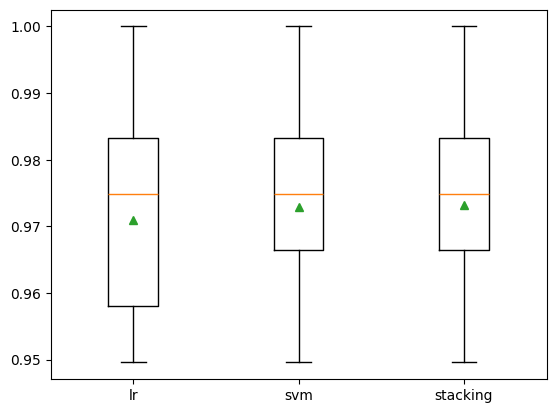

In [37]:
# compare ensemble to each baseline classifier
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from matplotlib import pyplot

# get the dataset
#def get_dataset():
#	X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=1)
#	return X, y

# get a stacking ensemble of models
def get_stacking():
	# define the base models
	level0 = list()
	level0.append(('lr', LogisticRegression(solver='liblinear')))
#	level0.append(('knn', KNeighborsClassifier()))
#	level0.append(('cart', DecisionTreeClassifier()))
	level0.append(('svm', SVC()))
	# define meta learner model
	level1 = LogisticRegression(max_iter=1000)
	# define the stacking ensemble
	model = StackingClassifier(estimators=level0, final_estimator=level1, cv=5)
	return model

# get a list of models to evaluate
def get_models():
	models = dict()
	models['lr'] = LogisticRegression(solver='liblinear')
#	models['knn'] = KNeighborsClassifier()
#	models['cart'] = DecisionTreeClassifier()
	models['svm'] = SVC()
	models['stacking'] = get_stacking()
	return models

# evaluate a give model using cross-validation
def evaluate_model(model, X, y):
	cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
	scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
	return scores


# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
	scores = evaluate_model(model, X_train_vec, Y_train)
	results.append(scores)
	names.append(name)
	print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

estimators = [
    ('svc', SVC(random_state=42)),
    ('nb', MultinomialNB())
]

model = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('stack', StackingClassifier(
        estimators=estimators,
        final_estimator=SVC(random_state=42)
    ))
])

model.fit(X_train, Y_train)

test_predict = model.predict(X_test)

train_accuracy = round(model.score(X_train,Y_train)*100)
test_accuracy =round(accuracy_score(test_predict, Y_test)*100)

print("AB Train Accuracy Score : {}% ".format(train_accuracy ))
print("AB Test Accuracy Score  : {}% ".format(test_accuracy ))
print()
print(classification_report(test_predict, Y_test, target_names=target_category))

AB Train Accuracy Score : 100% 
AB Test Accuracy Score  : 97% 

               precision    recall  f1-score   support

     business       0.97      0.93      0.95        70
         tech       0.95      1.00      0.97        52
     politics       0.96      0.95      0.95        56
        sport       1.00      1.00      1.00        69
entertainment       0.94      0.96      0.95        51

     accuracy                           0.97       298
    macro avg       0.96      0.97      0.97       298
 weighted avg       0.97      0.97      0.97       298



In [42]:
# from sklearn import metrics
# import matplotlib.pyplot as plt

# #define metrics
# y_pred_proba = modelSVC.predict_proba(X_test)[::,1]
# fpr, tpr, _ = metrics.roc_curve(Y_test,  y_pred_proba)
# auc = metrics.roc_auc_score(Y_test, y_pred_proba)

# #create ROC curve
# plt.plot(fpr,tpr,label="AUC="+str(auc))
# plt.ylabel('True Positive Rate')
# plt.xlabel('False Positive Rate')
# plt.legend(loc=4)
# plt.show()

### ROC

In [43]:
# from sklearn.metrics import roc_curve

# # predict probabilities
# pred_prob1 = modelSVC.predict_proba(X_test)
# pred_prob2 = modelDTC.predict_proba(X_test)
# pred_prob3 = modelRF.predict_proba(X_test)
# #pred_prob4 = modelGBC.predict_proba(X_test)
# pred_prob5 = modelLR.predict_proba(X_test)
# #pred_prob6 = modelMNB.predict_proba(X_test)
# pred_prob7 = modelKNN.predict_proba(X_test)
# # pred_prob8 = modelSGDC.predict_proba(X_test)
# # pred_prob9 = modelMLP.predict_proba(X_test)
# pred_prob10 = modelAB.predict_proba(X_test)
# pred_prob11 = modelNB.predict_proba(X_test)
# #pred_prob12 = modelLRMLP.predict_proba(X_test)

# #print(pred_prob1)

# # roc curve for models
# fpr1, tpr1, thresh1 = roc_curve(Y_test, pred_prob1[:,1], pos_label = 1)
# fpr2, tpr2, thresh2 = roc_curve(Y_test, pred_prob2[:,1], pos_label = 1)
# fpr3, tpr3, thresh3 = roc_curve(Y_test, pred_prob3[:,1], pos_label = 1)
# #fpr4, tpr4, thresh4 = roc_curve(Y_test, pred_prob4[:,1], pos_label = 1)
# fpr5, tpr5, thresh5 = roc_curve(Y_test, pred_prob5[:,1], pos_label = 1)
# #fpr6, tpr6, thresh6 = roc_curve(Y_test, pred_prob6[:,1], pos_label = 1)
# fpr7, tpr7, thresh7 = roc_curve(Y_test, pred_prob7[:,1], pos_label = 1)
# #fpr8, tpr8, thresh8 = roc_curve(Y_test, pred_prob8[:,1], pos_label = 1)
# #fpr9, tpr9, thresh9 = roc_curve(Y_test, pred_prob9[:,1], pos_label = 1)
# fpr10, tpr10, thresh10 = roc_curve(Y_test, pred_prob10[:,1], pos_label = 1)
# fpr11, tpr11, thresh11 = roc_curve(Y_test, pred_prob11[:,1], pos_label = 1)
# #fpr12, tpr12, thres12 = roc_curve(Y_test, pred_prob11[:,1], pos_label = 1)

# print(fpr11, tpr11)

# # roc curve for tpr = fpr
# random_probs = [0 for i in range(len(Y_test))]
# p_fpr, p_tpr, _ = roc_curve(Y_test, random_probs, pos_label=1)

In [44]:
# import seaborn as sb
# import matplotlib.pyplot as plt
# plt.style.use('seaborn')
# sb.set_theme(style = 'whitegrid')

# # plot roc curves
# plt.plot(fpr1, tpr1, linestyle = '--', color = 'magenta', label = 'SVM')
# plt.plot(fpr2, tpr2, linestyle = '--', color = 'green', label = 'DT')
# plt.plot(fpr3, tpr3, linestyle = '--', color = 'red', label = 'RF')
# #plt.plot(fpr4, tpr4, linestyle = '--', color = 'purple', label = 'GB')
# plt.plot(fpr5, tpr5, linestyle = '--', color = 'darkorange', label = 'LR')
# #plt.plot(fpr6, tpr6, linestyle = '--', color = 'pink', label = 'MNB')
# plt.plot(fpr7, tpr7, linestyle = '--', color = 'pink', label = 'KNN')
# #plt.plot(fpr8, tpr8, linestyle = '--', color = 'cyan', label = 'SGD')
# #plt.plot(fpr9, tpr9, linestyle = '--', color = 'blue', label = 'MLP')
# plt.plot(fpr10, tpr10, linestyle = '--', color = 'brown', label = 'AB')
# plt.plot(fpr11, tpr11, linestyle = '--', color = 'grey', label = 'NB')
# #plt.plot(fpr12, tpr12, linestyle = '--', color = 'green', label = 'LR-MLP')
# plt.plot(p_fpr, p_tpr, linestyle = '--', color = 'cornflowerblue')
# # title
# plt.title('ROC Curve')
# # x label
# plt.xlabel('False Positive Rate')
# # y label
# plt.ylabel('True Positive rate')

# plt.legend(loc='best')
# #plt.savefig('ROC',dpi=500)
# plt.show();